# Progetto finale

## Organizzazione dataframe
Cominciamo questo notebook introducendo i dati di riferimento per lo studio ed organizzandoli in unatabella unica facile da gestire

In [43]:
# importiamo i pacchetti necessari
import numpy as np 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import json

from pathlib import Path
from shapely.geometry import Point
from shapely.geometry import shape

# importazione del modulo con le funzioni
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from IPython.display import Image, display
import src.EDA_funcs as fs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# per facilitare la scrittura, introduciamo le directory dei dati
data_path_raw = Path('../data/raw')
data_path_ext = Path('../data/external')

files_raw = {'grid':'trentino-grid.geojson',
         'adm_reg':'ondata_confini_amministrativi_api_v2_it_20120101_unita-territoriali-sovracomunali_22_comuni.geo.json',
         'weather':'meteotrentino-weather-station-data.json',
         'precip':'precipitation-trentino.csv',
         'precip-avail':'precipitation-trentino-data-availability.csv',
         'SET-1':'SET-nov-2013.csv',
         'SET-2':'SET-dec-2013.csv',
         'SET-lines':'line.csv',
         'twitter':'social-pulse-trentino.geojson'}

files_ext = {'data_appa':'APPA_extended.csv',
              'pos_appa':'posizioni_stazioni_appa.csv'}

In [45]:
# importiamo la griglia con la geometria delle celle
grid_df = gpd.read_file(data_path_raw / files_raw['grid'])

### MeteoTrentino, ARPA
Cominciamo importando i dati ARPA legati al meteo ed organizzandoli su base oraria

In [46]:
with open(data_path_raw / files_raw['weather']) as f:
    weather_json = json.load(f)

weather = gpd.GeoDataFrame(weather_json['features'])

# notiamo come per un giorno manchino le misurazioni da parte di una stazione, per il momento riempiamo con nan
weather = fs.fill_hole(weather)

# splittiamo le colonne del vento in speed e direction
weather_df = fs.winds_split(weather)

# inseriamo una colonna geometry con la posizione delle stazioni
weather_df['geometry'] = weather_df['geomPoint.geom'].apply(lambda x:Point(x['coordinates'][0], x['coordinates'][1]))
weather_df.drop(columns=['geomPoint.geom'],inplace=True)

# modifichiamo il dataframe weather in modo che sia nella stessa forma degli altri dataframe
# -> facciamo in modo che ad ogni riga corrisponda un'ora (dato che il meteo viene misurato ogni quarto d'ora, mediamo sulle ore)
# NB: riferiamo ad una data ora X la media dei dati da (X-1):15 a X:00
weather_df = fs.restructure_weather(weather_df)

weather_df.head()

,station,date,hour,elevation,temperature,precipitation,winds_spd,winds_dir,geometry
0,T0032,2013-11-01,0,1155,7.300,0.0,NaN,NaN,POINT (11.25372 45.94027)
1,T0032,2013-11-01,1,1155,7.000,0.0,NaN,NaN,POINT (11.25372 45.94027)
2,T0032,2013-11-01,2,1155,6.675,0.0,NaN,NaN,POINT (11.25372 45.94027)
3,T0032,2013-11-01,3,1155,6.725,0.0,NaN,NaN,POINT (11.25372 45.94027)
4,T0032,2013-11-01,4,1155,6.925,0.0,NaN,NaN,POINT (11.25372 45.94027)


### APPA
Importiamo quindi i dati APPA

In [47]:
appa_df = pd.read_csv(data_path_ext / files_ext['data_appa'], encoding='latin1')

# convertiamo gli elementi nelle colonne 'Valore' e 'Ora' in valori numerici
appa_df['Valore'] = pd.to_numeric(appa_df['Valore'], errors='coerce')
appa_df['Ora'] = pd.to_numeric(appa_df['Ora'], errors='coerce')

# a partire da appa_pos, creiamo la colonna 'geometry' per appa_df.
appa_pos = pd.read_csv(data_path_ext / files_ext['pos_appa'])

appa_pos['geometry'] = appa_pos['Posizione'].apply(lambda x:Point(float(x.split(',')[1]),float(x.split(',')[0])))

# i nomi delle stazioni nei due dataset sono leggermente diversi, quindi li inseriamo manualmente
data_names = ['Piana Rotaliana', 'Riva del Garda', 'Monte Gaza', 'Parco S. Chiara', 'Rovereto', 'Via Bolzano','A22 (Avio)', 'Borgo Valsugana']
appa_pos['station'] = data_names

# cambiamo i nomi delle colonne di inquinanti
appa_df['Inquinante'] = appa_df['Inquinante'].replace({'Biossido Zolfo': 'SO2', 'Biossido di Azoto': 'NO2', 'Ossido di Carbonio': 'CO', 'Ozono': 'O3'})

appa_df.head()

,Stazione,Inquinante,Data,Ora,Valore,Unità di misura
0,Parco S. Chiara,PM10,2013-11-01,1,23.0,µg/mc
1,Parco S. Chiara,PM10,2013-11-01,2,25.0,µg/mc
2,Parco S. Chiara,PM10,2013-11-01,3,23.0,µg/mc
3,Parco S. Chiara,PM10,2013-11-01,4,21.0,µg/mc
4,Parco S. Chiara,PM10,2013-11-01,5,20.0,µg/mc


In [48]:
# spostiamo gli inquinanti su diverse colonne per facilitare il confronto
appa_df['Valore'] = pd.to_numeric(appa_df['Valore'], errors='coerce')
appa_comp_df = appa_df.pivot_table(index=['Stazione', 'Data', 'Ora'],columns='Inquinante', values='Valore').reset_index()
appa_comp_df.columns.name = None
appa_comp_df['geometry'] = appa_comp_df['Stazione'].map(appa_pos.set_index('station')['geometry'])
appa_comp_df = appa_comp_df.rename(columns={'Stazione': 'station', 'Data': 'date', 'Ora': 'hour'})
appa_comp_df.head()

,station,date,hour,CO,NO2,O3,PM10,PM2.5,SO2,geometry
0,A22 (Avio),2013-11-01,1,0.55,53.0,NaN,23.0,NaN,NaN,POINT (10.97043 45.74215)
1,A22 (Avio),2013-11-01,2,0.51,48.0,NaN,33.0,NaN,NaN,POINT (10.97043 45.74215)
2,A22 (Avio),2013-11-01,3,0.49,41.0,NaN,35.0,NaN,NaN,POINT (10.97043 45.74215)
3,A22 (Avio),2013-11-01,4,0.50,41.0,NaN,35.0,NaN,NaN,POINT (10.97043 45.74215)
4,A22 (Avio),2013-11-01,5,0.43,40.0,NaN,15.0,NaN,NaN,POINT (10.97043 45.74215)


Aggiungiamo l'indice di qualità dell'aria.
In particolare, facciamo riferimento alla classificazione europea EAQI, riportata nella tabella sotto. 
In vista del successivo studio ML assegnamo anche un valore numerico all'EAQI. Assegnamo un valore da 0 a 100, dividendo il range totale uniformemente tra i cinque scaglioni ed assegnando il valore interpolando linearmente tra gli estremi dell'intervallo

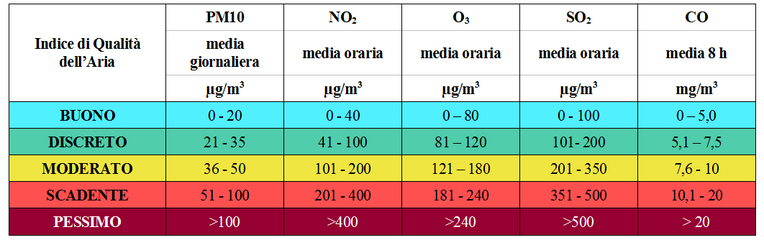

In [49]:
display(Image(filename='../images/TABELLA_APPA.png'))

In [59]:
# inseriamo l'EAQI numerico (lo chiamiamo AQI)
pol_intervals = {'PM2.5':[(0, 10), (10, 20), (20, 25), (25, 30), (30, np.inf)],  # la conversione per i PM2.5 è ricavata da un'altra tabella
                  'PM10':[(0, 20), (20, 35), (35, 50), (50, 100), (100, np.inf)],
                  'NO2':[(0, 40), (40, 100), (100, 200), (200, 400), (400, np.inf)],
                  'O3':[(0, 80), (80, 120), (120, 180), (180, 240), (240, np.inf)],
                  'SO2':[(0, 100), (100, 200), (200, 350), (350, 500), (500, np.inf)],
                  'CO':[(0, 5), (5, 7.5), (7.5, 10), (10, 20), (20, np.inf)]}

eaqi_nametags = ['good', 'fair', 'moderate', 'poor', 'very poor']

for pol in pol_intervals.keys():
    appa_comp_df['AQI_' + pol] = appa_comp_df[pol].apply(lambda x: fs.get_AQI_pol(x, pol_intervals[pol]))

AQI_cols = ['AQI_' + pol for pol in pol_intervals.keys()]

appa_comp_df['AQI'] = appa_comp_df[AQI_cols].max(axis=1)
appa_comp_df = appa_comp_df.drop(columns=AQI_cols)

# aggiungiamo il nametag EAQI
# divido per 20.0001 in modo che i numeri sul bordo finiscano nello scaglione  giusto
appa_comp_df['EAQI'] = appa_comp_df['AQI'].apply(lambda x: eaqi_nametags[int(x/20.0001)]) 

appa_comp_df.head()

,station,date,hour,CO,NO2,O3,PM10,PM2.5,SO2,geometry,AQI,EAQI,station_weather
1459,Borgo Valsugana,2013-11-01,1,NaN,21.0,2.0,19.0,12.0,NaN,POINT (11.45389 46.05184),24.0,fair,T0392
1460,Borgo Valsugana,2013-11-01,2,NaN,18.0,2.0,18.0,11.0,NaN,POINT (11.45389 46.05184),22.0,fair,T0392
1461,Borgo Valsugana,2013-11-01,3,NaN,19.0,2.0,19.0,12.0,NaN,POINT (11.45389 46.05184),24.0,fair,T0392
1462,Borgo Valsugana,2013-11-01,4,NaN,17.0,2.0,20.0,11.0,NaN,POINT (11.45389 46.05184),22.0,fair,T0392
1463,Borgo Valsugana,2013-11-01,5,NaN,18.0,2.0,21.0,13.0,NaN,POINT (11.45389 46.05184),26.0,fair,T0392


### POWER CONSUMPTION
Introduciamo infine le misurazioni legate ai consumi elettrici. 
Intuitivamente correliamo il consumo di elettricità con la produzione di inquinanti atmosferici. I dati sull'elettricità sono però disponibili cella per cella. Sapendo che la mobilità degli inquinanti è tendenzialmente anche abbastanza alta e non volendo aumentare troppo il numero di features, assegnando alle stazioni tutti i dati sulle celle vicine, vogliamo individuare un valore efficace per la potenza dissipata da assegnare ad ogni stazione appa (per ciascuna ora).

Si noti come i dati elettrici sono forniti in corrente (A). Per parlare di potenza assumiamo quindi tensione uguale in tutte le linee, per cui $P \propto I$, con lo stesso coefficiente di proporzionalità per tutte le linee. In questo limite, lavorare con la corrente o con la potenza è equivalente.

In [51]:
# creiamo i dataframe e li sistemiamo un minimo
power_names = ['lineset', 'datetime', 'power']
pow_nov_df = pd.read_csv(data_path_raw / files_raw['SET-1'],names=power_names)
pow_dec_df = pd.read_csv(data_path_raw / files_raw['SET-2'],names=power_names)
pow_pos_df = pd.read_csv(data_path_raw / files_raw['SET-lines'])

# concateniamo i dataframe con la potenza
lines_df = pd.concat([pow_nov_df, pow_dec_df], ignore_index=True)
lines_df = lines_df.sort_values(['lineset', 'datetime'])

# dato che gli inquinanti atmosferici sono misurati su base oraria, medio la potenza su ciascuna ora. 
# riferiamo ad una data ora X la media dei dati da (X-1):10 a X:00
lines_df['datetime'] = pd.to_datetime(lines_df['datetime'])
lines_df['hour_ref'] = (lines_df['datetime'] + pd.Timedelta(minutes=50)).dt.floor('h')
lines_df = lines_df.groupby(['lineset', 'hour_ref'])['power'].mean().reset_index()
lines_df['date'] = lines_df['hour_ref'].dt.date
lines_df['hour'] = lines_df['hour_ref'].dt.hour
lines_df = lines_df[['lineset', 'date', 'hour', 'power']]

lines_df.head()

,lineset,date,hour,power
0,DG1000420,2013-11-01,0,37.439999
1,DG1000420,2013-11-01,1,35.579999
2,DG1000420,2013-11-01,2,33.299998
3,DG1000420,2013-11-01,3,31.859998
4,DG1000420,2013-11-01,4,31.739998


In [52]:
# ciascuna linea elettrica distribuisce corrente elettrica su diverse celle. Mergiamo il df con la potenza per linea, con quello con il numero di ubicazioni 
# per cella a cui ogni linea fornisce energia. Assumendo un consumo uniforme per ubicazione, stimiamo poi quanta potenza venga effettivamente consumata in
# ciascuna cella.
sq_power_df = fs.get_square_power(pow_pos_df, lines_df)

# aggiungo la geometria alle celle grazie alla griglia
sq_power_df['geometry'] = sq_power_df['squareid'].map(grid_df.set_index('cellId')['geometry'])

sq_power_df.head()

,squareid,date,hour,power_square,geometry
0,155,2013-11-01,0,0.101565,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
1,155,2013-11-01,1,0.087188,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
2,155,2013-11-01,2,0.076522,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
3,155,2013-11-01,3,0.075768,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
4,155,2013-11-01,4,0.072870,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."


Proviamo a visualizzare le celle nella mappa

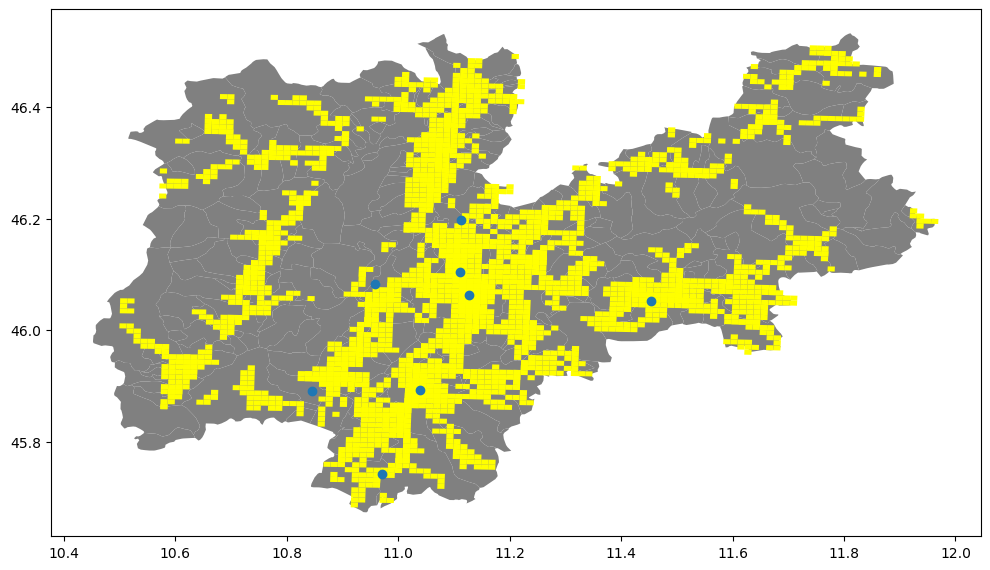

In [53]:
# importiamo il dataframe con i confini amministrativi
with open(data_path_raw / files_raw['adm_reg']) as f:
    admin_json = json.load(f)

admin_df = gpd.GeoDataFrame(admin_json['features'])
admin_df['geometry'] = admin_df['geometry'].apply(shape)
admin_df['municipality'] = admin_df['properties'].apply(lambda x: x['comune'])
admin_df = gpd.GeoDataFrame(admin_df,geometry='geometry')

pow_pos_df['geometry'] = pow_pos_df['SQUAREID'].map(grid_df.set_index('cellId')['geometry'])
pow_pos_df = gpd.GeoDataFrame(pow_pos_df,geometry='geometry')

appa_pos = gpd.GeoDataFrame(data=appa_pos,geometry='geometry')

fig, ax = plt.subplots(figsize=(12, 8))
# sovrapponiamo ai confini amministrativi la posizione delle stazioni e le celle presenti nei file SET
admin_df.plot(ax=ax, color='gray')
pow_pos_df.plot(ax=ax, color='yellow')
appa_pos.plot(ax=ax)

plt.show()

Si noti come non tutti i comuni sono raggiunti dalla rete SET (o perlomeno lo sono nei nostri dati). In particolare, Riva del Garda sembra completamente scollegata, per cui non abbiamo informazioni sulla potenza per la stazione appa in questa regione. Visto che non era comunque presene nei dati inizialmente forniti, preferiamo escludere questa stazione dallo studio nel momento in cui l'influenza dell'elettricità viene considerato

### Assegnazione di una potenza efficace alle stazioni APPA

Assumiamo che gli inquinanti vengano emessi a livello del suolo e vogliamo stimare fino a quale distanza possano essere trasportati prima di essere rilevati da una stazione APPA.

Esistono numerosi modelli di dispersione atmosferica (si veda ad esempio: https://it.wikipedia.org/wiki/Modelli_di_dispersione_in_atmosfera), ma una trattazione rigorosa va oltre gli obiettivi di questo progetto. Adotteremo quindi un modello volutamente semplice.

Trascurando il vento, il principale meccanismo di trasporto è la **diffusione turbolenta**, mentre il contributo del moto browniano è generalmente trascurabile.
Indichiamo con $K$ il coefficiente di diffusione turbolenta e assumiamo una dispersione isotropa. Si può quindi immaginare il raggio caratteristico di dispersione evolva come $r(t) = \sqrt{6Kt}$, dove $r$ è espresso in metri e $t$ in secondi.

$K$ in realtà varia di molto tra giorno e notte ed in base alla temperatura. Per semplicità assumiamo $K=10$, che dovrebbe essere un valore abbastanza neutro. Si ha quindi:
- $r(1h) \simeq 500$ m
- $r(3h) \simeq 800$ m
- $r(6h) \simeq 1100$ m
- $r(12h) \simeq 1600$ m
- $r(24h) \simeq 2300$ m

Possiamo quindi immaginare che prendendo in considerazione un cerchio di raggio 2.5 km e centrato sulla data stazione, dovremmo star considerando appieno la possibile produzione di inquinanti a causa di attività energivore.

Dato che non conosciamo neanche l'effettiva influenza di questa eventuale feature, non ha neanche senso fare studi troppo complessi a riguardo. Scegliamo quindi di costruirci tre colonne contenenti:
- la potenza dissipata entro 50 metri (in modo da tenere conto delle stazioni al limite tra celle diverse)
- la potenza dissipata entro 1000 metri
- la potenza dissipata entro 2500 metri

Per il momento limitiamoci ad inserire queste colonne nella tabella. Successivamente proveremo ad indagare anche la correlazione shiftata nel tempo.

In [54]:
# passiamo dalla notazione standard GPS alla notazione in metri
grid_df_mt = grid_df.set_crs('EPSG:4326').to_crs('EPSG:32632')
appa_pos = gpd.GeoDataFrame(data=appa_pos,geometry='geometry')
appa_pos_mt = appa_pos.set_crs('EPSG:4326').to_crs('EPSG:32632')

radius = [50, 1000, 2500] # m
dfs = []
for r in radius:
    appa_buffer = appa_pos_mt.copy()
    appa_buffer[f'geometry_buffer_{r}'] = appa_buffer.geometry.buffer(r)
    appa_buffer = appa_buffer.set_geometry(f'geometry_buffer_{r}')
    area_df = gpd.sjoin(appa_buffer,grid_df_mt,predicate='intersects',how='inner')
    area_df = area_df[['station', 'geometry', f'geometry_buffer_{r}', 'cellId']]
    area_df = pd.merge(area_df,sq_power_df,left_on='cellId',right_on='squareid',how='left')
    area_df = area_df.groupby(['station', 'geometry_x', f'geometry_buffer_{r}', 'date', 'hour'])['power_square'].sum().reset_index()
    area_df = area_df[['station', 'date', 'hour', 'power_square']] 
    area_df = area_df.rename(columns={'power_square': f'power_area_{r}'})  

    dfs.append(area_df)

final_power_df = dfs[0]
for df in dfs[1:]:
    final_power_df = pd.merge(final_power_df,df,on=['station', 'date', 'hour'],how='left')

final_power_df['hour'] = final_power_df['hour'].astype(int)

final_power_df.head()

,station,date,hour,power_area_50,power_area_1000,power_area_2500
0,A22 (Avio),2013-11-01,0,0.613197,7.820284,50.692246
1,A22 (Avio),2013-11-01,1,0.575491,6.829341,45.485803
2,A22 (Avio),2013-11-01,2,0.540203,6.076843,41.331046
3,A22 (Avio),2013-11-01,3,0.517080,5.974915,40.208050
4,A22 (Avio),2013-11-01,4,0.477067,5.698521,37.861077


#### Stiamo prendendo aree sufficientemente grandi?

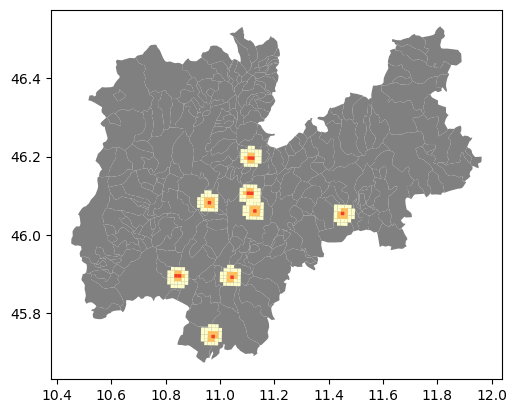

In [55]:
grid_df_mt = grid_df.set_crs('EPSG:4326').to_crs('EPSG:32632')
appa_pos_mt = appa_pos.set_crs('EPSG:4326').to_crs('EPSG:32632')

radius = [2500, 1000, 50] # m
dfs = []
for r in radius:    
    appa_buffer = appa_pos_mt.copy()
    appa_buffer[f'geometry_buffer_{r}'] = appa_buffer.geometry.buffer(r)
    appa_buffer = appa_buffer.set_geometry(f'geometry_buffer_{r}')
    area_df = gpd.sjoin(appa_buffer,grid_df_mt,predicate='intersects',how='inner')
    area_df = area_df[['station', 'geometry', f'geometry_buffer_{r}', 'cellId']]
    area_df = pd.merge(area_df,grid_df,on='cellId',how='left')
    area_df = gpd.GeoDataFrame(data=area_df,geometry='geometry_y')

    dfs.append(area_df)

cmap = plt.cm.YlOrRd

# coloro ogni zona da rosso a giallo a seconda della distanza dalla stazione APPA
ax = admin_df.plot(color='gray')
for r in range(len(radius)):
    dfs[r].plot(ax = ax,color=cmap(r / len(radius)))

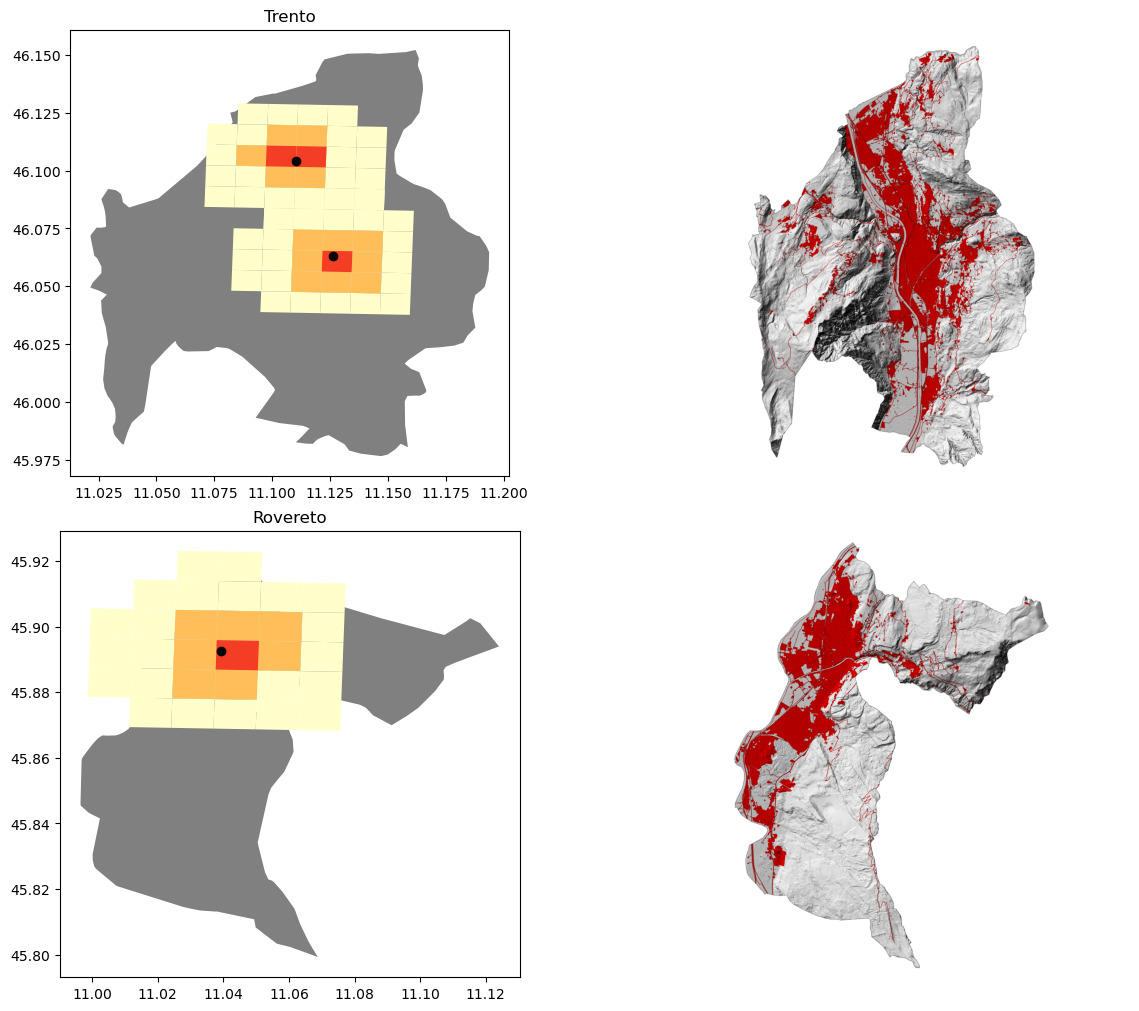

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Trento
ax = axes[0][0]
admin_df[admin_df['municipality'] == 'Trento'].plot(ax=ax,color='gray')
for r in range(len(radius)):
    dfs[r][(dfs[r]['station'] == 'Parco S. Chiara') | (dfs[r]['station'] == 'Via Bolzano')].plot(ax=ax,color=cmap(r / len(radius)))
appa_pos[(appa_pos['station'] == 'Parco S. Chiara') | (appa_pos['station'] == 'Via Bolzano')].plot(ax=ax,color='black')
ax.set_title('Trento')

img = mpimg.imread('../images/Trento.png')
axes[0][1].imshow(img)
axes[0][1].axis('off')

# Riva del Garda
ax = axes[1][0]
admin_df[admin_df['municipality'] == 'Rovereto'].plot(ax=ax,color='gray')
for r in range(len(radius)):
    dfs[r][dfs[r]['station'] == 'Rovereto'].plot(ax=ax,color=cmap(r / len(radius)))
appa_pos[appa_pos['station'] == 'Rovereto'].plot(ax=ax,color='black')
ax.set_title('Rovereto')

img = mpimg.imread('../images/Rovereto.png')
axes[1][1].imshow(img)
axes[1][1].axis('off')

plt.show()

Stiamo prendendo una parte considerevole di ciascun comune. Non penso che nell'assunzione di no vento le particelle inquinanti possano muoversi più di così.
Si tenga anche conto di come il Trentino sia particolarmente montuoso, per cui, si può notare dai due esempi, anche allargando l'area si andrebbero a comprendere prevalentemente montagne

### Creazione DataFrame completo
Dopo aver creato separatamente i DataFrame per gli inquinanti, per il meteo e per i consumi elettrici, uniamo infine i dati in un unico DataFrame da utilizzare poi nell'EDA e nel training.

In [57]:
# assegnamo le rilevazioni meteo a quelle appa associando ai dati appa quelli delle stazioni meteo vicine
# assumiamo una distanza sensata entro cui il meteo non cambia in maniera incisiva (per lo meno la temperatura e le precipitazioni) sia entro 1km di raggio
m_df = gpd.GeoDataFrame(weather_df[['station','geometry']].drop_duplicates(), geometry='geometry')
a_df = gpd.GeoDataFrame(appa_comp_df[['station','geometry']].drop_duplicates(), geometry='geometry')

# passiamo alla geometria in metri
a_df = a_df.set_crs('EPSG:4326').to_crs(32632)
m_df = m_df.set_crs('EPSG:4326').to_crs(32632)

# NB: notiamo come, l'unica stazione appa che non ha stazioni meteo entro i 4000 metri è la stazione di Avio.
# per questa stazione la stazione meteo più vicina è a circa 6500 metri. Distanza che riteniamo troppo grande perché i dati meteo siano effettivamente affidabili.
# visto che questa stazione non era neanche nel dataframe fornito con il progetto, preferiamo escludere la stazione dallo studio.
# fissiamo quindi il raggio R a 4km, in modo che ogni stazione appa faccia riferimento ad una stazione meteo.

# creiamo l'area di influenza e assegnamo la stazione più vicina
R = 4000
a_df['geometry'] = a_df.geometry.buffer(R)
map_df = gpd.sjoin(m_df,a_df,predicate='within',how='inner')

# mergiamo i dataframe sulla base della stazione più vicina
appa_comp_df['station_weather'] = appa_comp_df['station'].map(map_df.set_index('station_right')['station_left'])

# escludiamo la stazione di Avio
appa_comp_df = appa_comp_df[appa_comp_df['station'] != 'A22 (Avio)']

# correggo il formato della data, che se no non li riesce a confrontare
appa_comp_df['date'] = pd.to_datetime(appa_comp_df['date']).dt.date
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date

# finiamo il merge
final_df = appa_comp_df.merge(weather_df,left_on=['station_weather','date','hour'],right_on=['station','date','hour'],suffixes=('_appa','_weather'))
final_df = final_df.T.drop_duplicates().T # si crea una colonna duplicata station_weather, togliamola

# aggiungo i dati sulla potenza dissipata
# correggo il formato della data, che se no li vede diversi

final_power_df['date'] = pd.to_datetime(final_power_df['date']).dt.date

final_df = final_df.merge(final_power_df,left_on=['station_appa','date','hour'],right_on=['station','date','hour'],how='left')
final_df = final_df.drop(columns='station')

# chiudo aggiungendo una colonna con il giorno della settimana
final_df['week_day'] = pd.to_datetime(final_df['date']).dt.weekday.astype(str)
day = {'0':'monday', '1':'tuesday', '2':'wednesday', '3':'thursday', '4':'friday', '5':'saturday', '6':'sunday'}
final_df['week_day'] = final_df['week_day'].map(day)

final_df.to_csv("../data/processed/dataset_EDA_processed.csv", index=False)

final_df.head()

,station_appa,date,hour,CO,NO2,O3,PM10,PM2.5,SO2,geometry_appa,...,elevation,temperature,precipitation,winds_spd,winds_dir,geometry_weather,power_area_50,power_area_1000,power_area_2500,week_day
0,Borgo Valsugana,2013-11-01,1,NaN,21.0,2.0,19.0,12.0,NaN,POINT (11.45389 46.05184),...,410,11.35,0.0,NaN,NaN,POINT (11.47747769 46.05804607),17.760273,42.946772,54.704690,friday
1,Borgo Valsugana,2013-11-01,2,NaN,18.0,2.0,18.0,11.0,NaN,POINT (11.45389 46.05184),...,410,11.525,0.0,NaN,NaN,POINT (11.47747769 46.05804607),16.362439,39.762416,52.679229,friday
2,Borgo Valsugana,2013-11-01,3,NaN,19.0,2.0,19.0,12.0,NaN,POINT (11.45389 46.05184),...,410,11.425,0.0,NaN,NaN,POINT (11.47747769 46.05804607),17.861264,41.283915,50.294214,friday
3,Borgo Valsugana,2013-11-01,4,NaN,17.0,2.0,20.0,11.0,NaN,POINT (11.45389 46.05184),...,410,11.075,0.0,NaN,NaN,POINT (11.47747769 46.05804607),14.669913,36.119279,45.105859,friday
4,Borgo Valsugana,2013-11-01,5,NaN,18.0,2.0,21.0,13.0,NaN,POINT (11.45389 46.05184),...,410,10.95,0.0,NaN,NaN,POINT (11.47747769 46.05804607),16.969367,39.626135,48.951222,friday
